<a href="https://colab.research.google.com/github/rtafurthgarcia/COM763/blob/main/COM763_2526_Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Classification Algorithm Comparison

In this notebook, we compare **6 popular classification algorithms** on the **Breast Cancer Wisconsin dataset** (loaded directly from scikit-learn).

### Algorithms Compared:
| # | Algorithm |
|---|---|
| 1 | Logistic Regression |
| 2 | Support Vector Machine (SVM) |
| 3 | Decision Tree |
| 4 | Random Forest |
| 5 | K-Nearest Neighbors (KNN) |
| 6 | AdaBoost |

### Goal:
- Understand how each algorithm performs on the same dataset
- Compare Accuracy, Precision, Recall, and F1-Score
- Visualize results clearly

---

## 📦 Step 1 — Import Libraries

We import everything we need up front: data tools, the classifiers, and evaluation metrics.

In [ ]:
# Standard data libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import load_breast_cancer

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

# Settings
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


## 📊 Step 2 — Load & Explore the Dataset

We use the **Breast Cancer Wisconsin dataset** from scikit-learn.

- **569 samples**, **30 features** (measurements from cell nuclei)
- **Binary target**: Malignant (0) or Benign (1)
- No missing values — great for a clean comparison!

In [ ]:
# Load the dataset directly from scikit-learn
data = load_breast_cancer()

# Put it into a DataFrame for easier exploration
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print('Dataset Shape:', df.shape)
print('\nClass Distribution:')
print(df['target'].value_counts().rename({0: 'Malignant', 1: 'Benign'}))
print('\nFirst 5 rows:')
df.head()

Dataset Shape: (569, 31)

Class Distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [ ]:
# Check for missing values — should be none
print('Missing values per column:')
print(df.isnull().sum().sum(), 'total missing values')

# Quick summary statistics
df.describe().round(2)

Missing values per column:
0 total missing values


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08,0.63
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02,0.48
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06,0.00
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07,0.00
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08,1.00
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09,1.00
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21,1.00


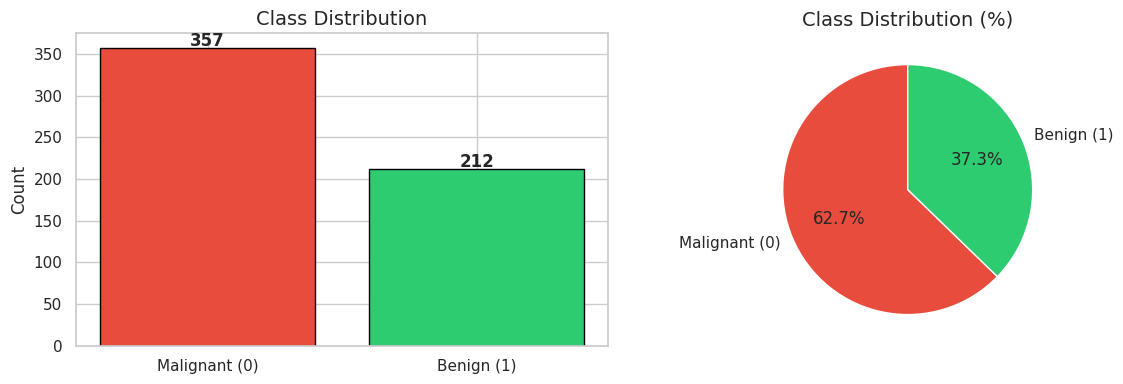

In [ ]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
class_counts = df['target'].value_counts()
axes[0].bar(['Malignant (0)', 'Benign (1)'], class_counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values,
            labels=['Malignant (0)', 'Benign (1)'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14)

plt.tight_layout()
plt.show()

## ✂️ Step 3 — Prepare the Data

Before training, we need to:
1. **Split** the data into training (80%) and testing (20%) sets
2. **Scale** the features — many algorithms (SVM, KNN, Logistic Regression) are sensitive to feature magnitude

> ⚠️ We fit the scaler **only on training data** and apply it to both train and test — this avoids *data leakage*.

In [ ]:
# Separate features (X) and target (y)
X = data.data
y = data.target

# Split into train/test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ensures same class balance in both splits
)

print(f'Training samples : {X_train.shape[0]}')
print(f'Testing samples  : {X_test.shape[0]}')
print(f'Number of features: {X_train.shape[1]}')

Training samples : 455
Testing samples  : 114
Number of features: 30


In [ ]:
# Scale the features using StandardScaler (mean=0, std=1)
scaler = StandardScaler()

# Fit ONLY on training data, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Features scaled successfully!')

Features scaled successfully!


## 🏋️ Step 4 — Train & Evaluate All Classifiers

We define all 6 classifiers with sensible default parameters, train each one, and collect their performance metrics.

> **Note**: Decision Trees and Random Forests don't strictly need scaling, but it doesn't hurt them either.

In [ ]:
# Define all 6 classifiers with default / simple parameters
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM':                 SVC(kernel='rbf', random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'AdaBoost':            AdaBoostClassifier(n_estimators=100, random_state=42)
}

In [ ]:
# Train each classifier and collect results
results = []

for name, clf in classifiers.items():
    # Train the model
    clf.fit(X_train_scaled, y_train)

    # Predict on the test set
    y_pred = clf.predict(X_test_scaled)

    # Calculate metrics
    acc       = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)

    # Store results
    results.append({
        'Model'     : name,
        'Accuracy'  : round(acc, 4),
        'Precision' : round(precision, 4),
        'Recall'    : round(recall, 4),
        'F1 Score'  : round(f1, 4)
    })

    print(f'{name:22s} -> Accuracy: {acc:.4f} | F1: {f1:.4f}')

# Convert to DataFrame for display
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1  # start ranking from 1

print('\n✅ All models trained!')

Logistic Regression    -> Accuracy: 0.9825 | F1: 0.9861
SVM                    -> Accuracy: 0.9825 | F1: 0.9861
Decision Tree          -> Accuracy: 0.9211 | F1: 0.9362
Random Forest          -> Accuracy: 0.9561 | F1: 0.9655
KNN                    -> Accuracy: 0.9561 | F1: 0.9655
AdaBoost               -> Accuracy: 0.9561 | F1: 0.9660

✅ All models trained!


## 📋 Step 5 — Results Summary Table

Here we compare all models side by side. The table is sorted by **Accuracy** (highest first).

**Metrics explained:**
- **Accuracy** — overall correct predictions
- **Precision** — of predicted positives, how many are truly positive
- **Recall** — of actual positives, how many were correctly found
- **F1 Score** — harmonic mean of Precision and Recall (useful for imbalanced classes)

In [ ]:
# Display results table with color highlighting
results_df.style\
    .background_gradient(subset=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                         cmap='YlGn')\
    .set_caption('📊 Model Comparison — sorted by Accuracy')\
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}',
             'Recall': '{:.4f}', 'F1 Score': '{:.4f}'})

,Model,Accuracy,Precision,Recall,F1 Score
1,Logistic Regression,0.9825,0.9861,0.9861,0.9861
2,SVM,0.9825,0.9861,0.9861,0.9861
3,Random Forest,0.9561,0.9589,0.9722,0.9655
4,KNN,0.9561,0.9589,0.9722,0.9655
5,AdaBoost,0.9561,0.9467,0.9861,0.9660
6,Decision Tree,0.9211,0.9565,0.9167,0.9362


## 📊 Step 6 — Visual Comparison of All Metrics

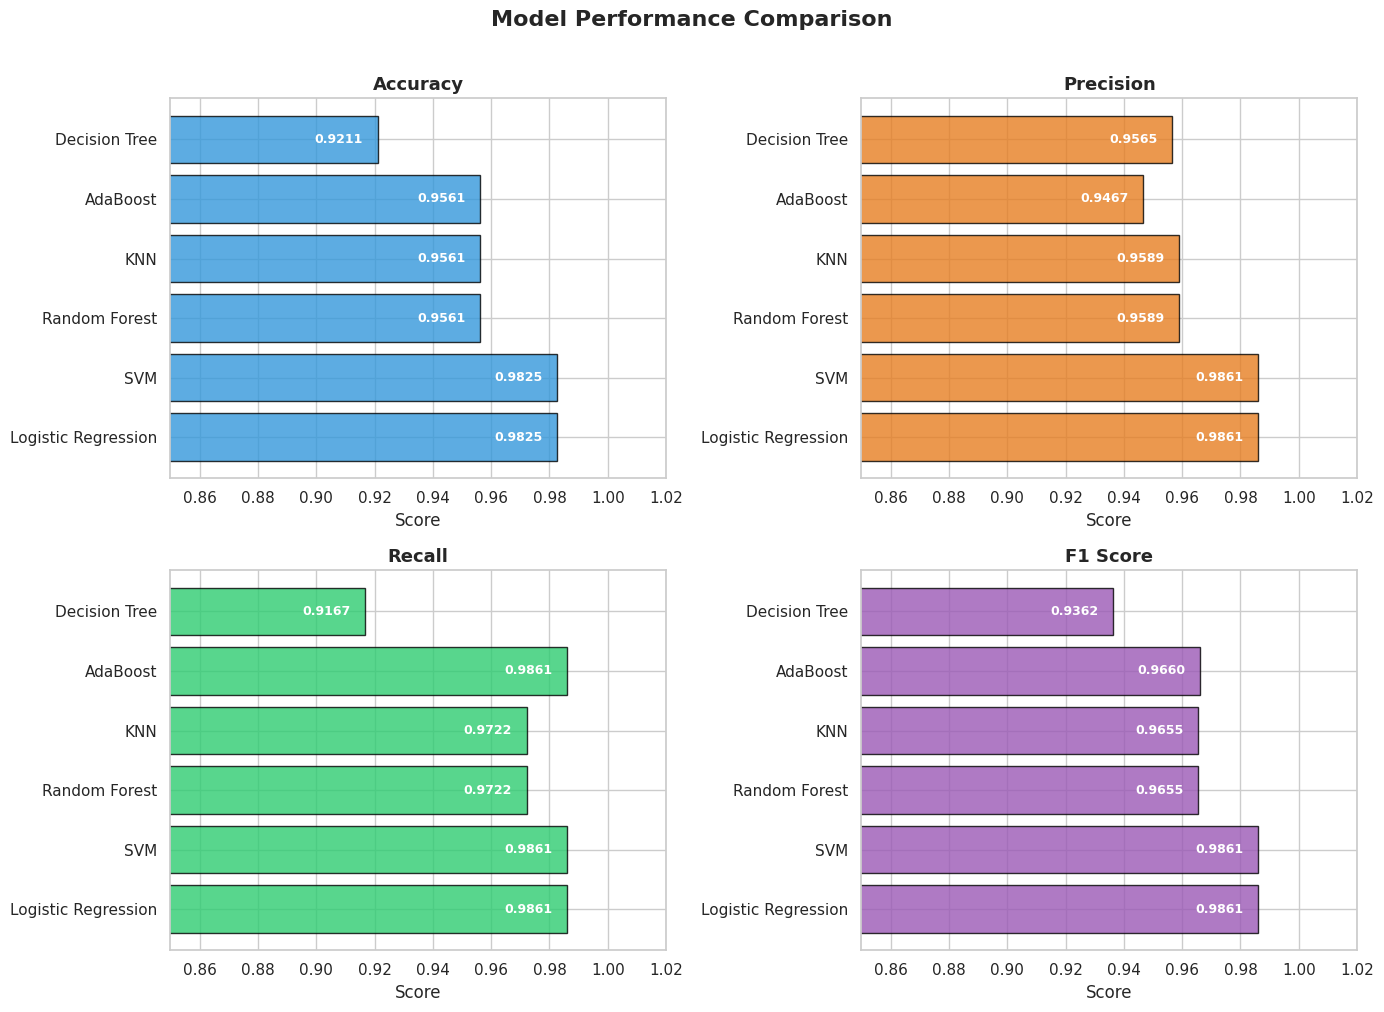

In [ ]:
# Bar chart comparing all 4 metrics across models
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
models    = results_df['Model'].tolist()
colors    = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes      = axes.flatten()

for i, (metric, color) in enumerate(zip(metrics, colors)):
    values = results_df[metric].tolist()
    bars   = axes[i].barh(models, values, color=color, alpha=0.8, edgecolor='black')

    # Add value labels on bars
    for bar, val in zip(bars, values):
        axes[i].text(val - 0.005, bar.get_y() + bar.get_height() / 2,
                     f'{val:.4f}', va='center', ha='right',
                     color='white', fontweight='bold', fontsize=9)

    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_xlim(0.85, 1.02)
    axes[i].set_xlabel('Score')

plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

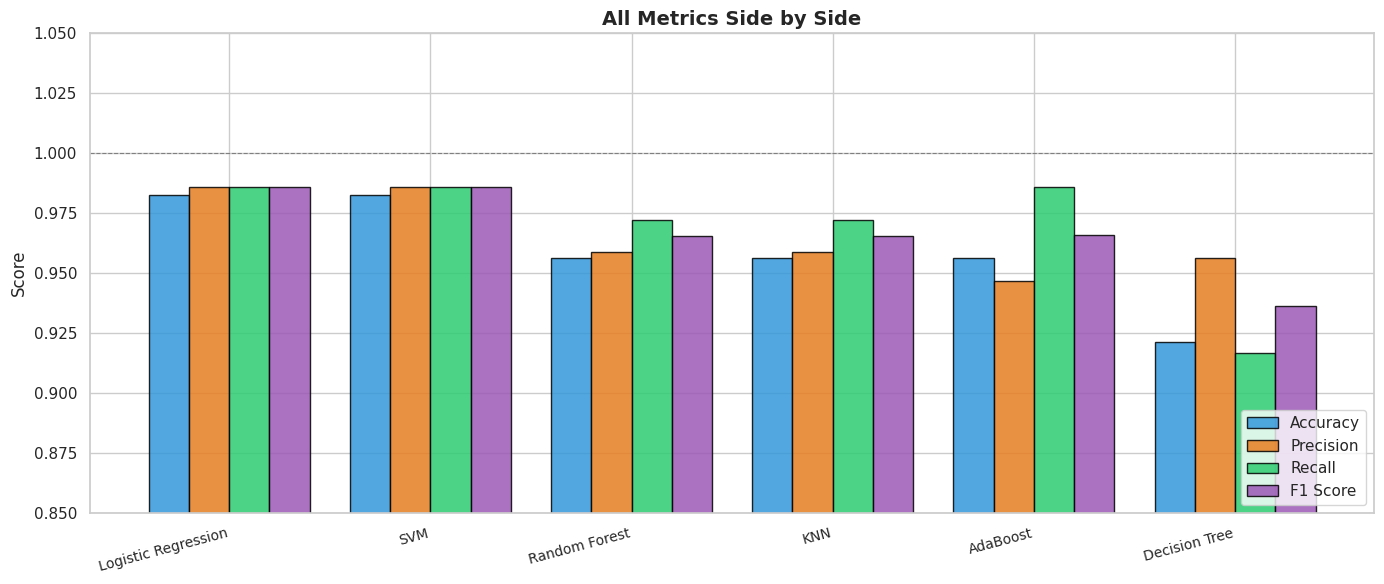

In [ ]:
# Grouped bar chart — all metrics side by side
x      = np.arange(len(models))
width  = 0.2
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = (i - 1.5) * width
    ax.bar(x + offset, results_df[metric], width, label=metric,
           color=color, alpha=0.85, edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.set_ylim(0.85, 1.05)
ax.set_ylabel('Score')
ax.set_title('All Metrics Side by Side', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.axhline(y=1.0, color='grey', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

## 🔲 Step 7 — Confusion Matrices

A confusion matrix shows:
- **True Positives (TP)** — correctly predicted positives
- **True Negatives (TN)** — correctly predicted negatives
- **False Positives (FP)** — predicted positive but actually negative
- **False Negatives (FN)** — predicted negative but actually positive

In a medical context like this, **False Negatives are most dangerous** (missed cancer cases).

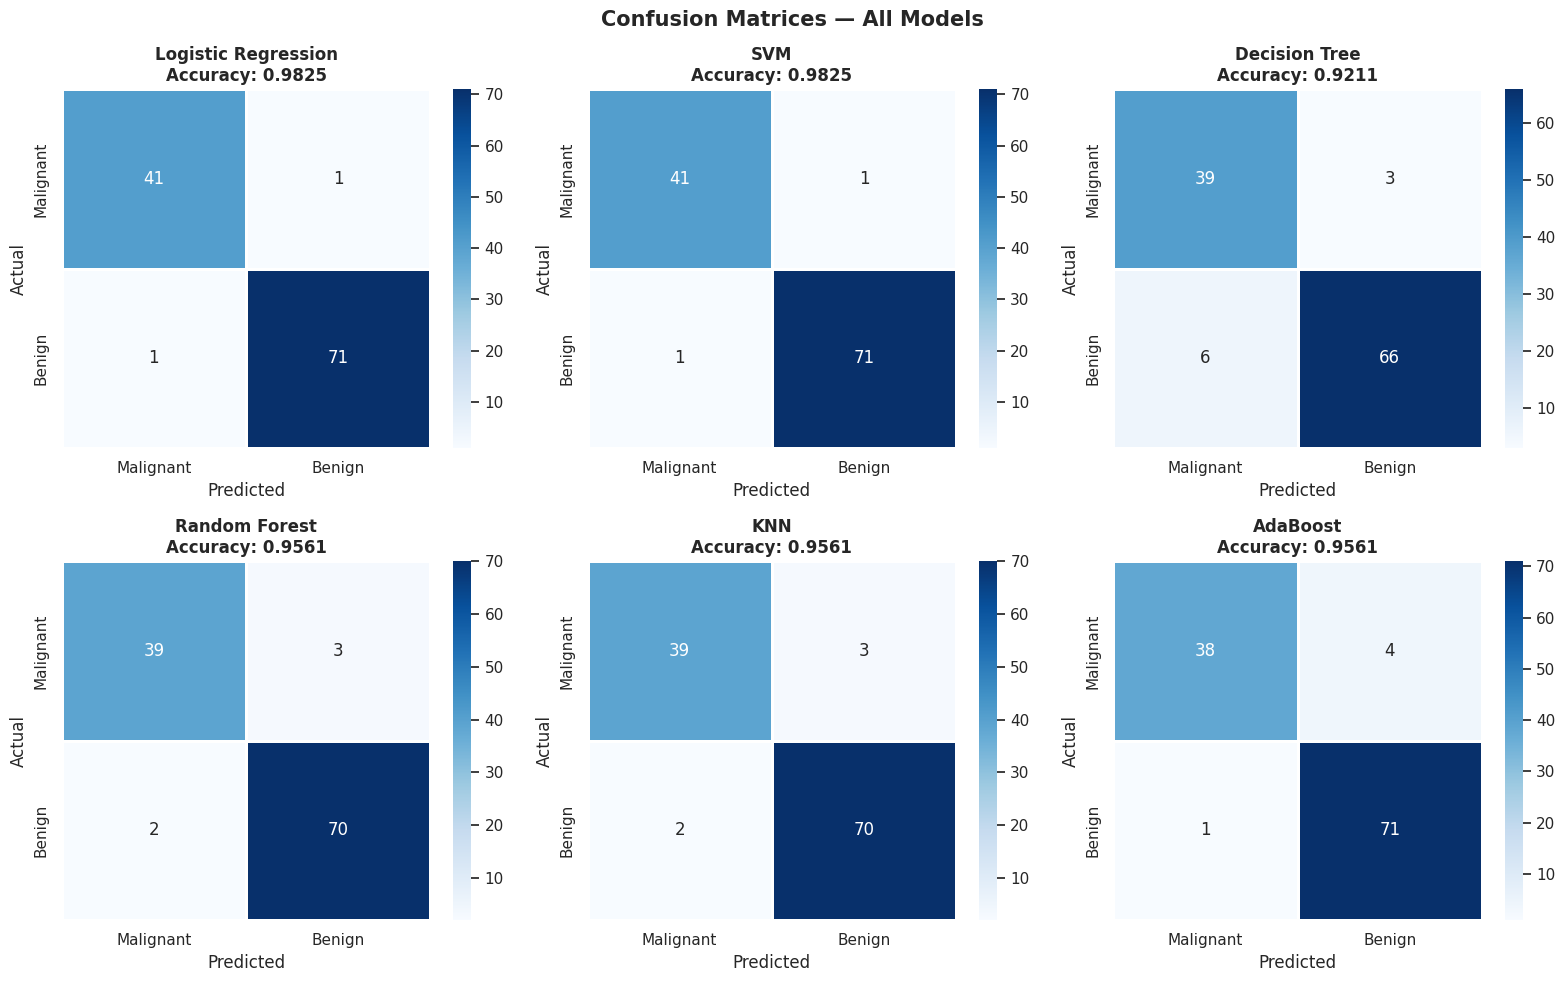

In [ ]:
# Plot confusion matrices for all 6 models
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, clf) in enumerate(classifiers.items()):
    # Get predictions
    y_pred = clf.predict(X_test_scaled)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'],
                ax=axes[i], linewidths=1)

    acc = accuracy_score(y_test, y_pred)
    axes[i].set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🌲 Step 8 — Feature Importance (Random Forest)

Random Forests can tell us which features were most useful for making predictions.
This helps with **interpretability** and can guide future feature selection.

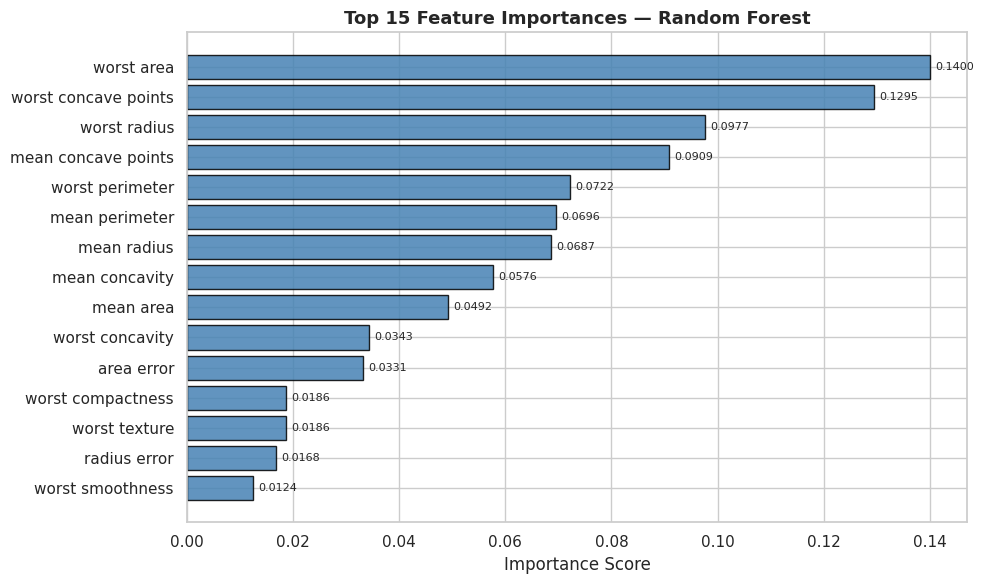

In [ ]:
# Get feature importances from the trained Random Forest
rf_model = classifiers['Random Forest']
importances = rf_model.feature_importances_

# Create a DataFrame and sort by importance
feat_df = pd.DataFrame({
    'Feature'   : data.feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(15)  # top 15

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'],
               color='steelblue', edgecolor='black', alpha=0.85)

ax.invert_yaxis()  # highest importance at the top
ax.set_xlabel('Importance Score')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{width:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 📌 Conclusions

### Key Takeaways:

| Algorithm | Strengths | Weaknesses |
|---|---|---|
| **Logistic Regression** | Fast, interpretable, great baseline | Assumes linear decision boundary |
| **SVM** | Powerful with good kernel, handles high dimensions | Slow on large datasets, needs scaling |
| **Decision Tree** | Interpretable, no scaling needed | Prone to overfitting |
| **Random Forest** | High accuracy, feature importance, robust | Less interpretable, slower |
| **KNN** | Simple, non-parametric | Slow at prediction, sensitive to scale |
| **AdaBoost** | Reduces bias, good accuracy | Sensitive to noise and outliers |

### When to use each:
- **Need interpretability?** → Logistic Regression or Decision Tree
- **Best raw performance?** → Random Forest or SVM
- **Quick prototype?** → KNN
- **Boosting weak learners?** → AdaBoost

---
*Dataset: Breast Cancer Wisconsin | Source: `sklearn.datasets.load_breast_cancer()`*